# J10 — Transport de solutés et modélisation inverse

**Physique et hydrodynamique des sols** — S. J. Gumiere

*Atelier du Jour 10 : solutions analytiques de l'ADE, courbes de percée HYDRUS-1D, soluté réactif, estimation inverse de paramètres*

> Version **instructeur** : code complet et résultats.

## Mise en place

Colonne de référence (projets HYDRUS `J10_*`) : loam sableux, régime permanent $q = 10$ cm/j vers le bas, $\theta = 0{,}3293$,
$v = q/\theta \approx 30{,}4$ cm/j, $L = 60$ cm, injection $c_0 = 1$ pendant $t_0 = 0{,}5$ j (masse injectée $q c_0 t_0 = 5$),
$D_0 = 1$ cm²/j, tortuosité de Millington–Quirk $\tau = \theta^{7/3}/\theta_s^2$, $D = \lambda v + D_0\tau$.
Convention HYDRUS : flux positif vers le haut (`cvBot` < 0 = sortie par le bas) ; dans les solutions analytiques, $x$ est la
distance parcourue vers le bas. Exécutez la cellule suivante pour importer les bibliothèques et définir la colonne.

In [1]:
import sys
sys.path.insert(0, "..")
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import erfc
from scipy.optimize import curve_fit, least_squares
from scipy.linalg import solve_banded
from hydrus_io import read_solute, read_obs_node

HYD = "../../hydrus"

# colonne de référence des projets HYDRUS J10_*
q = 10.0          # flux d'eau vers le bas (cm/j), régime permanent
theta = 0.3293    # teneur en eau (-)
theta_s = 0.41    # teneur en eau à saturation (-)
L = 60.0          # longueur de la colonne (cm)
t0 = 0.5          # durée de l'injection (j)
D0 = 1.0          # diffusion moléculaire dans l'eau libre (cm²/j)

v = q / theta                            # vitesse de pore (cm/j)
tau = theta ** (7 / 3) / theta_s ** 2    # tortuosité de Millington-Quirk (-)
De = D0 * tau                            # diffusion effective dans le sol (cm²/j)
print(f"v = {v:.2f} cm/j ; tau = {tau:.3f} ; De = {De:.3f} cm²/j")

v = 30.37 cm/j ; tau = 0.445 ; De = 0.445 cm²/j


## Exercice 1 — Solutions analytiques de l'équation d'advection–dispersion  *(≈ 15 min)*

1. Écrire `c_echelon(x, t, v, D, R, mu)` : concentration relative $c/c_0$ pour une injection **continue** (échelon) commençant
   à $t = 0$, solution d'Ogata–Banks généralisée au retard $R$ et à la dégradation du premier ordre $\mu$. Avec $v' = v/R$,
   $D' = D/R$ et $u = v'\sqrt{1 + 4\mu D'/v'^2}$ :
   $$\frac{c}{c_0} = \tfrac12\, e^{(v'-u)x/2D'}\,\mathrm{erfc}\!\left(\frac{x - ut}{2\sqrt{D't}}\right)
   + \tfrac12\, e^{(v'+u)x/2D'}\,\mathrm{erfc}\!\left(\frac{x + ut}{2\sqrt{D't}}\right).$$
   Sans retard ni dégradation ($R = 1$, $\mu = 0$) on a $u = v$ et on retrouve la formule classique
   $\tfrac12[\mathrm{erfc}((x-vt)/2\sqrt{Dt}) + e^{vx/D}\,\mathrm{erfc}((x+vt)/2\sqrt{Dt})]$.
2. Écrire `c_creneau(x, t, v, D, t0, R, mu)` pour une injection de durée $t_0$ : différence de deux échelons décalés de $t_0$
   (linéarité de l'ADE).
3. Pour $\lambda = 2$ cm, tracer les profils $c(z)$ à $t$ = 0,25, 0,5, 1, 1,5 et 2 j.
4. Pour $\lambda$ = 0,5, 2 et 10 cm ($D = \lambda v + D_e$) : tracer les courbes de percée (BTC) à 60 cm, vérifier la masse
   $\int_0^\infty q\,c\,dt = 5$ (`np.trapezoid`), calculer $Pe = vL/D$, le temps et la hauteur du pic et le temps moyen ;
   commenter.

**1. Solution pour un échelon (Ogata–Banks généralisée)**

In [2]:
# concentration relative c/c0 à la distance x (cm) et au temps t (j) pour une injection continue
# commençant à t = 0 ; R : facteur de retard (-), mu : constante de dégradation (1/j)
def c_echelon(x, t, v, D, R, mu):
    vR = v / R                                    # vitesse et dispersion effectives (retard)
    DR = D / R
    u = vR * np.sqrt(1 + 4 * mu * DR / vR**2)     # u = vR quand mu = 0
    racine = 2 * np.sqrt(DR * t)
    terme1 = np.exp((vR - u) * x / (2 * DR)) * erfc((x - u * t) / racine)
    terme2 = np.exp((vR + u) * x / (2 * DR)) * erfc((x + u * t) / racine)
    return 0.5 * (terme1 + terme2)

# vérifications : c = c0 à l'entrée ; c = 0 loin devant le front ; c -> c0 partout aux temps longs
print("c/c0 à x = 0, t = 1 j      :", round(c_echelon(0.0, 1.0, v, 61.0, 1.0, 0.0), 4))
print("c/c0 à x = 60 cm, t = 0,5 j :", round(c_echelon(60.0, 0.5, v, 61.0, 1.0, 0.0), 4))
print("c/c0 à x = 60 cm, t = 6 j   :", round(c_echelon(60.0, 6.0, v, 61.0, 1.0, 0.0), 4))

c/c0 à x = 0, t = 1 j      : 1.0
c/c0 à x = 60 cm, t = 0,5 j : 0.0
c/c0 à x = 60 cm, t = 6 j   : 1.0


**2. Injection de durée t0 (créneau)**

In [3]:
# injection de durée t0 : échelon qui commence à t = 0 moins un échelon qui commence à t = t0
def c_creneau(x, t, v, D, t0, R, mu):
    c1 = c_echelon(x, t, v, D, R, mu)
    t2 = np.maximum(t - t0, 1e-9)                 # temps écoulé depuis la fin de l'injection
    c2 = c_echelon(x, t2, v, D, R, mu)
    c2 = np.where(t > t0, c2, 0.0)                # le second échelon n'existe qu'après t0
    return c1 - c2

print("c/c0 à x = 60 cm, t = 2 j :", round(c_creneau(60.0, 2.0, v, 61.0, t0, 1.0, 0.0), 4))
print("c/c0 à x = 60 cm, t = 6 j :", round(c_creneau(60.0, 6.0, v, 61.0, t0, 1.0, 0.0), 4))

c/c0 à x = 60 cm, t = 2 j : 0.3983
c/c0 à x = 60 cm, t = 6 j : 0.0


**3. Profils c(z) pour lambda = 2 cm**

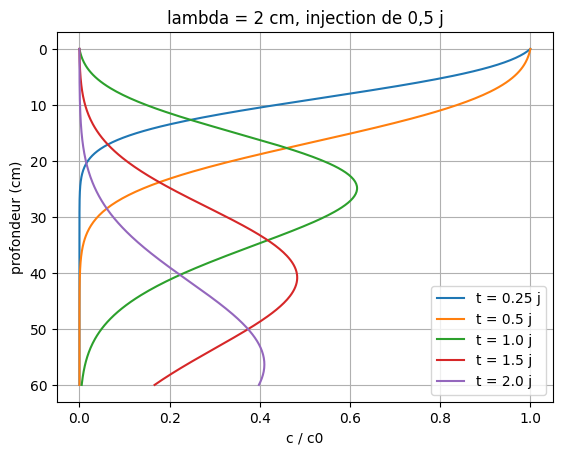

In [4]:
D = 2.0 * v + De                 # coefficient de dispersion hydrodynamique (cm²/j)
zz = np.linspace(0, 60, 300)     # profondeurs (cm)

plt.figure()
for t_ in [0.25, 0.5, 1.0, 1.5, 2.0]:
    c = c_creneau(zz, t_, v, D, t0, 1.0, 0.0)
    plt.plot(c, zz, label=f"t = {t_} j")
plt.gca().invert_yaxis()
plt.xlabel("c / c0")
plt.ylabel("profondeur (cm)")
plt.title("lambda = 2 cm, injection de 0,5 j")
plt.legend()
plt.grid(True)
plt.show()

**4. Courbes de percée à 60 cm : effet de la dispersivité**

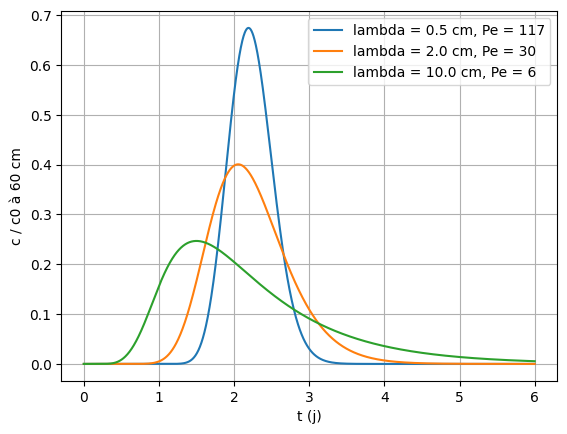

   lambda_cm  D_cm2_j       Pe  masse  t_pic  c_pic  t_moyen
0        0.5   15.629  116.580  5.000  2.190  0.674    2.226
1        2.0   61.180   29.782  5.000  2.054  0.401    2.226
2       10.0  304.120    5.991  4.941  1.498  0.247    2.167
centre de masse théorique L/v + t0/2 = 2.226 j


In [5]:
tt = np.linspace(0.001, 6, 1500)    # temps (j)
resultats = []

plt.figure()
for lam in [0.5, 2.0, 10.0]:
    D = lam * v + De
    cf = c_creneau(L, tt, v, D, t0, 1.0, 0.0)
    Pe = v * L / D                                     # nombre de Péclet de la colonne
    masse = np.trapezoid(q * cf, tt)                   # masse sortie (cm · c0)
    t_pic = tt[np.argmax(cf)]
    c_pic = np.max(cf)
    t_moyen = np.trapezoid(tt * cf, tt) / np.trapezoid(cf, tt)
    resultats.append([lam, D, Pe, masse, t_pic, c_pic, t_moyen])
    plt.plot(tt, cf, label=f"lambda = {lam} cm, Pe = {Pe:.0f}")
plt.xlabel("t (j)")
plt.ylabel("c / c0 à 60 cm")
plt.legend()
plt.grid(True)
plt.show()

tableau = pd.DataFrame(resultats, columns=["lambda_cm", "D_cm2_j", "Pe", "masse", "t_pic", "c_pic", "t_moyen"])
print(tableau.round(3))
print("centre de masse théorique L/v + t0/2 =", round(L / v + t0 / 2, 3), "j")

**Commentaire (instructeur).** La masse est conservée à $10^{-4}$ près pour $\lambda$ = 0,5 et 2 cm (pour 10 cm, 1 % de la masse n'est pas encore sortie à 6 j) ;
le centre de masse arrive à $L/v + t_0/2 = 2{,}23$ j quelle que soit $\lambda$, mais le pic est d'autant plus précoce et bas
que $D$ est grand (2,19 → 2,05 → 1,50 j ; 0,67 → 0,40 → 0,25) : l'asymétrie de la BTC en temps est une propriété de l'ADE, pas un
artefact. La solution d'Ogata–Banks utilisée ici est une concentration **de flux** (eau qui sort) ; la concentration **résidente**
(eau en place, mesurée par une sonde) en diffère d'autant plus que $Pe$ est petit.

## Exercice 2 — Courbes de percée HYDRUS-1D et méthode des moments  *(≈ 15 min)*

Projets `J10_traceur_disp0.5cm`, `J10_traceur_disp2cm`, `J10_traceur_disp10cm` (mêmes conditions, $\lambda$ = 0,5 / 2 / 10 cm).

1. Lire `solute1.out` (`read_solute`) ; la concentration de flux à la sortie est $c_f = -$`cvBot`$/q$. Tracer les BTC HYDRUS
   avec la solution analytique `c_creneau` pour les trois $\lambda$ ; calculer la RMSE de chaque projet.
2. Lire `OBS_NODE.OUT` (`read_obs_node`, variable `Conc`, nœuds 21, 41, 81, 121 = 10, 20, 40, 60 cm) pour $\lambda$ = 2 cm et
   tracer les concentrations aux quatre profondeurs.
3. Bilan de masse : `Sum(cvTop)` (masse injectée) et `Sum(cvBot)` (masse sortie) à 6 j.
4. Moments temporels de $c_f(60, t)$ : $M_0 = \int c_f\,dt$, $\bar t$, $\sigma_t^2$ ; en déduire $v = L/(\bar t - t_0/2)$ et
   $D = (\sigma_t^2 - t_0^2/12)\,v^3/(2L)$ ; comparer aux valeurs imposées ; expliquer l'écart pour $\lambda$ = 10 cm.

**Lecture des données**

In [6]:
so_05 = read_solute(f"{HYD}/J10_traceur_disp0.5cm")
so_2 = read_solute(f"{HYD}/J10_traceur_disp2cm")
so_10 = read_solute(f"{HYD}/J10_traceur_disp10cm")
print(so_2[["cvTop", "cvBot", "Sum(cvTop)", "Sum(cvBot)"]].head())

        cvTop  cvBot  Sum(cvTop)  Sum(cvBot)
Time                                        
0.0010   10.0    0.0     0.01000         0.0
0.0020   10.0    0.0     0.02000         0.0
0.0033   10.0    0.0     0.03300         0.0
0.0050   10.0    0.0     0.04990         0.0
0.0072   10.0    0.0     0.07187         0.0


**1. BTC HYDRUS et solution analytique**

lambda =  0.5 cm : D =   15.63 cm²/j, Pe =  116.6, RMSE HYDRUS - analytique = 0.0013
lambda =  2.0 cm : D =   61.18 cm²/j, Pe =   29.8, RMSE HYDRUS - analytique = 0.0024
lambda = 10.0 cm : D =  304.12 cm²/j, Pe =    6.0, RMSE HYDRUS - analytique = 0.0093


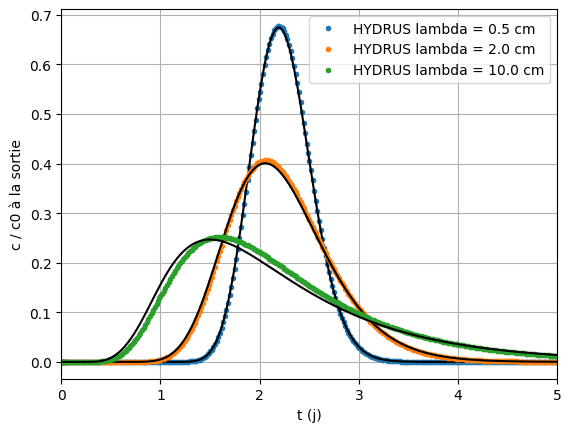

In [7]:
plt.figure()
for lam, so in [(0.5, so_05), (2.0, so_2), (10.0, so_10)]:
    t_h = so.index.to_numpy()                     # temps HYDRUS (j)
    cf_h = -so["cvBot"].to_numpy() / q            # concentration de flux à la sortie (cvBot < 0 = sortie)
    D = lam * v + De
    cf_a = c_creneau(L, t_h, v, D, t0, 1.0, 0.0)  # solution analytique aux mêmes temps
    rmse = np.sqrt(np.mean((cf_h - cf_a) ** 2))
    print(f"lambda = {lam:4} cm : D = {D:7.2f} cm²/j, Pe = {v * L / D:6.1f}, RMSE HYDRUS - analytique = {rmse:.4f}")
    plt.plot(t_h, cf_h, ".", label=f"HYDRUS lambda = {lam} cm")
    plt.plot(t_h, cf_a, "k-")
plt.xlabel("t (j)")
plt.ylabel("c / c0 à la sortie")
plt.xlim(0, 5)
plt.legend()
plt.grid(True)
plt.show()

**2. Concentrations aux nœuds d'observation (lambda = 2 cm)**

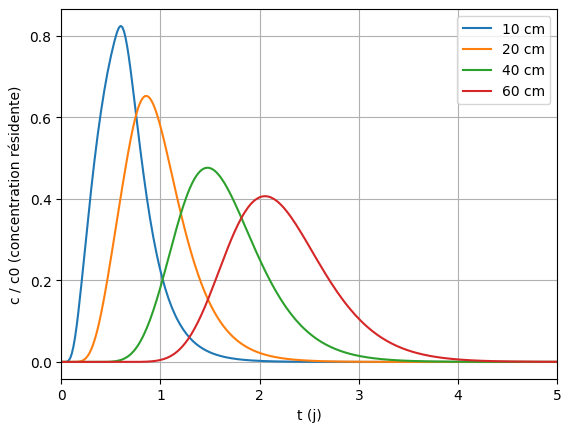

In [8]:
ob = read_obs_node(f"{HYD}/J10_traceur_disp2cm")

plt.figure()
plt.plot(ob.index, ob[(21, "Conc")], label="10 cm")
plt.plot(ob.index, ob[(41, "Conc")], label="20 cm")
plt.plot(ob.index, ob[(81, "Conc")], label="40 cm")
plt.plot(ob.index, ob[(121, "Conc")], label="60 cm")
plt.xlabel("t (j)")
plt.ylabel("c / c0 (concentration résidente)")
plt.xlim(0, 5)
plt.legend()
plt.grid(True)
plt.show()

**3. Bilan de masse**

In [9]:
for lam, so in [(0.5, so_05), (2.0, so_2), (10.0, so_10)]:
    masse_injectee = so["Sum(cvTop)"].iloc[-1]
    masse_sortie = -so["Sum(cvBot)"].iloc[-1]
    print(f"lambda = {lam:4} cm : masse injectée = {masse_injectee:.3f}, masse sortie à 6 j = {masse_sortie:.3f}")

lambda =  0.5 cm : masse injectée = 5.000, masse sortie à 6 j = 5.000
lambda =  2.0 cm : masse injectée = 5.000, masse sortie à 6 j = 5.000
lambda = 10.0 cm : masse injectée = 5.000, masse sortie à 6 j = 4.963


**4. Méthode des moments : v et D estimés**

In [10]:
resultats = []
for lam, so in [(0.5, so_05), (2.0, so_2), (10.0, so_10)]:
    t_h = so.index.to_numpy()
    cf_h = -so["cvBot"].to_numpy() / q
    # moments temporels de la BTC
    M0 = np.trapezoid(cf_h, t_h)                                      # aire sous la courbe (j)
    t_moyen = np.trapezoid(t_h * cf_h, t_h) / M0                      # temps moyen (j)
    variance = np.trapezoid((t_h - t_moyen) ** 2 * cf_h, t_h) / M0    # variance temporelle (j²)
    # paramètres de transport déduits des moments (injection de durée t0)
    v_est = L / (t_moyen - t0 / 2)
    D_est = (variance - t0 ** 2 / 12) * v_est ** 3 / (2 * L)
    resultats.append([lam, q * M0, t_moyen, variance, v_est, v, D_est, lam * v + De])

tableau = pd.DataFrame(resultats, columns=["lambda_cm", "masse", "t_moyen", "variance", "v_estime", "v_impose", "D_estime", "D_impose"])
print(tableau.round(3))

   lambda_cm  masse  t_moyen  variance  v_estime  v_impose  D_estime  D_impose
0        0.5  5.000    2.225     0.087    30.372    30.367    15.372    15.629
1        2.0  5.000    2.225     0.273    30.372    30.367    58.820    61.180
2       10.0  4.963    2.190     0.938    30.921    30.367   225.876   304.120


**Commentaire (instructeur).** HYDRUS reproduit la solution analytique à mieux que 1 % (RMSE 0,001–0,009) : maillage de 0,5 cm (Péclet de maille 0,05 à 1) et
Crank–Nicolson. La masse injectée (5,00) ressort intégralement pour $\lambda$ = 0,5 et 2 cm ; pour 10 cm, 0,04 manque encore à 6 j
(traînée). Aux nœuds d'observation, la concentration résidente arrive d'autant plus tard et plus étalée que le nœud est profond.
Les moments retrouvent $v$ à 0,1 % près et $D$ à −3 % ($\lambda$ = 2 cm), mais sous-estiment $D$ de 25 % pour $\lambda$ = 10 cm :
la variance est dominée par la traînée tronquée. Règle : n'utiliser les moments que sur une BTC complète ($M_0$ ≥ 98 % de la masse injectée).

## Exercice 3 — Soluté réactif : retard, dégradation et ajustement de ($K_d$, $\mu$)  *(≈ 15 min)*

`J10_nitrate_reactif` : mêmes conditions que `J10_traceur_disp2cm` avec sorption linéaire $K_d = 0{,}2$ cm³/g ($\rho_b = 1{,}5$ g/cm³)
et dégradation du premier ordre $\mu = 0{,}05$ /j (phases liquide et adsorbée).

1. Calculer le facteur de retard $R = 1 + \rho_b K_d/\theta$. Tracer les BTC de sortie du traceur et du soluté réactif (HYDRUS)
   avec les solutions analytiques (`c_creneau` avec $R$ et $\mu$, puis avec $R$ seul). Temps du pic et temps moyen de chaque BTC ;
   rapport réactif/traceur ; comparer à $R$.
2. Masse récupérée à 6 j (`Sum(cvBot)`) vs masse injectée ; comparer à $M e^{-\mu \bar t}$ et à l'intégrale de la solution
   analytique jusqu'à $t = 40$ j.
3. Ajuster ($K_d$, $\mu$) par `curve_fit` sur la BTC HYDRUS du soluté réactif ($v$ et $D$ connus) depuis (0,1 ; 0,02) :
   écarts-types, corrélation $K_d$–$\mu$ ; tracer l'ajustement.
4. Refaire l'ajustement avec la seule partie montante de la BTC ($t < 3{,}5$ j) : que deviennent les écarts-types et la corrélation ?

**Lecture des données**

In [11]:
rho_b = 1.5      # masse volumique apparente (g/cm³)
Kd = 0.2         # coefficient de distribution (cm³/g)
mu = 0.05        # constante de dégradation (1/j)
D = 2.0 * v + De # dispersion pour lambda = 2 cm (cm²/j)

so_t = read_solute(f"{HYD}/J10_traceur_disp2cm")
so_n = read_solute(f"{HYD}/J10_nitrate_reactif")
t_t = so_t.index.to_numpy()
cf_t = -so_t["cvBot"].to_numpy() / q     # BTC du traceur
t_n = so_n.index.to_numpy()
cf_n = -so_n["cvBot"].to_numpy() / q     # BTC du soluté réactif

**1. Facteur de retard, BTC et temps caractéristiques**

facteur de retard R = 1.91


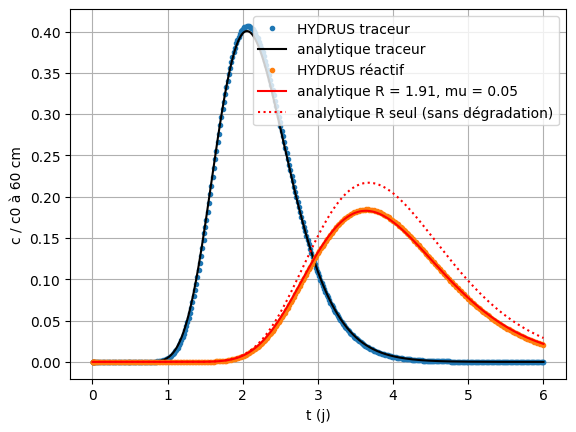

pic : traceur 2.07 j, réactif 3.64 j, rapport 1.76
temps moyen : traceur 2.23 j, réactif 3.89 j
R observé = (t_r - t0/2) / (t_t - t0/2) = 1.84 (théorie 1.91 ; la BTC réactive est tronquée à 6 j)


In [12]:
R = 1 + rho_b * Kd / theta
print(f"facteur de retard R = {R:.2f}")

tt = np.linspace(0.001, 6, 1500)
plt.figure()
plt.plot(t_t, cf_t, ".", label="HYDRUS traceur")
plt.plot(tt, c_creneau(L, tt, v, D, t0, 1.0, 0.0), "k-", label="analytique traceur")
plt.plot(t_n, cf_n, ".", label="HYDRUS réactif")
plt.plot(tt, c_creneau(L, tt, v, D, t0, R, mu), "r-", label=f"analytique R = {R:.2f}, mu = {mu}")
plt.plot(tt, c_creneau(L, tt, v, D, t0, R, 0.0), "r:", label="analytique R seul (sans dégradation)")
plt.xlabel("t (j)")
plt.ylabel("c / c0 à 60 cm")
plt.legend()
plt.grid(True)
plt.show()

# temps du pic
t_pic_t = t_t[np.argmax(cf_t)]
t_pic_n = t_n[np.argmax(cf_n)]
print(f"pic : traceur {t_pic_t:.2f} j, réactif {t_pic_n:.2f} j, rapport {t_pic_n / t_pic_t:.2f}")

# temps moyen (premier moment) de chaque BTC
M0_t = np.trapezoid(cf_t, t_t)
tb_t = np.trapezoid(t_t * cf_t, t_t) / M0_t
M0_n = np.trapezoid(cf_n, t_n)
tb_n = np.trapezoid(t_n * cf_n, t_n) / M0_n
R_obs = (tb_n - t0 / 2) / (tb_t - t0 / 2)
print(f"temps moyen : traceur {tb_t:.2f} j, réactif {tb_n:.2f} j")
print(f"R observé = (t_r - t0/2) / (t_t - t0/2) = {R_obs:.2f} (théorie {R:.2f} ; la BTC réactive est tronquée à 6 j)")

**2. Masse récupérée et dégradation**

In [13]:
masse_injectee = so_n["Sum(cvTop)"].iloc[-1]
masse_traceur = -so_t["Sum(cvBot)"].iloc[-1]
masse_reactif = -so_n["Sum(cvBot)"].iloc[-1]
print(f"masse injectée {masse_injectee:.3f} ; récupérée à 6 j : traceur {masse_traceur:.3f}, réactif {masse_reactif:.3f}")

# estimation simple : la masse se dégrade pendant le temps moyen de séjour R L/v + t0/2
t_sejour = R * L / v + t0 / 2
masse_exp = masse_injectee * np.exp(-mu * t_sejour)
print(f"M exp(-mu t_sejour) = {masse_exp:.3f} (t_sejour = {t_sejour:.2f} j)")

# intégrale de la solution analytique jusqu'à 40 j (BTC complète)
t_long = np.linspace(0.001, 40, 8000)
masse_analytique = np.trapezoid(q * c_creneau(L, t_long, v, D, t0, R, mu), t_long)
print(f"intégrale analytique 0-40 j = {masse_analytique:.3f}")

masse injectée 5.000 ; récupérée à 6 j : traceur 5.000, réactif 3.985
M exp(-mu t_sejour) = 4.088 (t_sejour = 4.03 j)
intégrale analytique 0-40 j = 4.145


**3. Ajustement de (Kd, mu) sur la BTC complète**

BTC complète : Kd = 0.2004 ± 0.0001 cm³/g, mu = 0.0497 ± 0.0002 /j, corrélation = -0.080


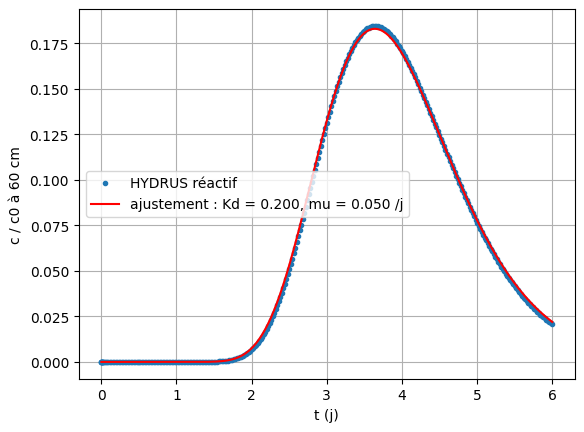

In [14]:
# modèle de BTC à la sortie en fonction des deux paramètres à ajuster (v, D, t0 connus)
def btc_reactif(t, Kd_aj, mu_aj):
    R_aj = 1 + rho_b * Kd_aj / theta
    return c_creneau(L, t, v, D, t0, R_aj, mu_aj)

popt, pcov = curve_fit(btc_reactif, t_n, cf_n, p0=[0.1, 0.02], bounds=([0, 0], [2, 1]))
Kd_est = popt[0]
mu_est = popt[1]
se_Kd = np.sqrt(pcov[0, 0])
se_mu = np.sqrt(pcov[1, 1])
corr_Kd_mu = pcov[0, 1] / (se_Kd * se_mu)
print(f"BTC complète : Kd = {Kd_est:.4f} ± {se_Kd:.4f} cm³/g, mu = {mu_est:.4f} ± {se_mu:.4f} /j, corrélation = {corr_Kd_mu:.3f}")

plt.figure()
plt.plot(t_n, cf_n, ".", label="HYDRUS réactif")
plt.plot(tt, btc_reactif(tt, Kd_est, mu_est), "r-", label=f"ajustement : Kd = {Kd_est:.3f}, mu = {mu_est:.3f} /j")
plt.xlabel("t (j)")
plt.ylabel("c / c0 à 60 cm")
plt.legend()
plt.grid(True)
plt.show()

**4. Ajustement sur la partie montante seulement (t < 3,5 j)**

In [15]:
montee = t_n < 3.5
popt2, pcov2 = curve_fit(btc_reactif, t_n[montee], cf_n[montee], p0=[0.1, 0.02], bounds=([0, 0], [2, 1]))
se2 = np.sqrt(np.diag(pcov2))
corr2 = pcov2[0, 1] / (se2[0] * se2[1])
print(f"partie montante : Kd = {popt2[0]:.4f} ± {se2[0]:.4f} cm³/g, mu = {popt2[1]:.4f} ± {se2[1]:.4f} /j, corrélation = {corr2:.3f}")

partie montante : Kd = 0.2033 ± 0.0000 cm³/g, mu = 0.0424 ± 0.0001 /j, corrélation = -0.897


**Commentaire (instructeur).** Le pic est retardé d'un facteur 1,76 et le centre de masse d'un facteur ≈ 1,9 = $R$ (la BTC réactive n'est pas terminée à 6 j, d'où
un $\bar t$ légèrement sous-estimé, 1,84). Environ 17 % de la masse est dégradée ($e^{-\mu\bar t}$ = 0,82) : HYDRUS restitue 3,98 à 6 j
et la solution analytique 4,15 sur une BTC complète. L'ajustement sur la BTC complète retrouve $K_d$ = 0,20 et $\mu$ = 0,05 avec des
écarts-types de quelques pour cent et une corrélation quasi nulle ; sur la seule partie montante, $\mu$ est biaisé (0,042) et les deux
paramètres deviennent fortement corrélés ($r = -0{,}9$ : un retard plus grand et une dégradation plus faible produisent la même montée) :
il faut la descente et la masse totale pour les séparer.

## Exercice 4 — Modélisation inverse : estimer ($\alpha$, $n$, $K_s$) avec un solveur de Richards  *(≈ 20 min)*

`data/J10_inverse_donnees.csv` : infiltration cumulée $I(t)$ ($\sigma_I$ = 0,2 cm) et charges de pression à 10, 30 et 50 cm
($\sigma_h$ = 3 cm), toutes les 0,05 j pendant 1 j, pour une infiltration submergée ($h_{top} = 0$) dans un loam à $h_0 = -100$ cm
(données de `J06_infiltration_submergee_loam` bruitées). $\theta_r = 0{,}078$ et $\theta_s = 0{,}43$ sont connus.

Le solveur `richards(alpha, n, Ks)` est fourni (forme mixte de Celia et al., itérations de Picard, système tridiagonal résolu par
`solve_banded`, Mualem–van Genuchten, $dz$ = 1 cm, $dt$ = 0,005 j) : il renvoie $I$ et $h$ aux mêmes instants que les données.

1. Vérifier le solveur avec les vrais paramètres (0,036 ; 1,56 ; 24,96) : temps d'un appel, RMSE par rapport aux données.
2. Écrire la fonction `residu` des résidus pondérés $r_i = (y_i^{obs} - y_i(\mathbf b))/\sigma_i$ pour
   $\mathbf b = \log(\alpha, n, K_s)$ et lancer `least_squares` (bornes : $\alpha \in [0{,}005 ; 0{,}2]$, $n \in [1{,}15 ; 3]$,
   $K_s \in [2 ; 500]$ ; `diff_step=0.02`, `xtol=ftol=1e-4`) depuis (0,02 ; 1,8 ; 50). Temps de calcul, nombre d'évaluations,
   paramètres estimés.
3. Covariance $\mathbf C = s^2(\mathbf J^T\mathbf J)^{-1}$ avec $s^2 = \Phi_{min}/(N - p)$ (`res.jac`, `res.cost` $= \Phi/2$) ;
   écarts-types, IC 95 % relatifs, matrice de corrélation ; tracer les données et le modèle ajusté.
4. Refaire l'estimation avec $I(t)$ seule : que deviennent les incertitudes et les corrélations ? Conclure sur l'identifiabilité.
5. Décrire la marche à suivre équivalente dans HYDRUS-1D (Main Processes → Inverse Solution ; types de données 0 et 1).

**Lecture des données**

In [16]:
don = pd.read_csv("data/J10_inverse_donnees.csv")
t_obs = don["t_j"].to_numpy()
I_obs = don["I_cm"].to_numpy()
h_obs = don[["h10_cm", "h30_cm", "h50_cm"]].to_numpy()
sigma_I = 0.2    # écart-type des mesures d'infiltration (cm)
sigma_h = 3.0    # écart-type des mesures de charge (cm)
theta_r = 0.078
theta_s = 0.43
print(don.head())

    t_j   I_cm  h10_cm  h30_cm  h50_cm
0  0.05  1.819   -6.97  -98.70 -107.27
1  0.10  3.539   -2.75 -103.02 -101.69
2  0.15  4.626    0.43 -101.60 -102.59
3  0.20  5.702    0.34  -11.47 -105.79
4  0.25  7.276    1.34    0.92 -102.39


**Fonctions hydrauliques de Mualem–van Genuchten (données)**

In [17]:
# teneur en eau (h en cm ; h >= 0 : sol saturé)
def vg_theta(h, alpha, n):
    m = 1 - 1 / n
    Se = (1 + (alpha * np.abs(h)) ** n) ** (-m)
    Se[h >= 0] = 1.0
    return theta_r + (theta_s - theta_r) * Se

# conductivité hydraulique (cm/j)
def vg_K(h, alpha, n, Ks):
    m = 1 - 1 / n
    Se = (1 + (alpha * np.abs(h)) ** n) ** (-m)
    Se[h >= 0] = 1.0
    return Ks * np.sqrt(Se) * (1 - (1 - Se ** (1 / m)) ** m) ** 2

# capacité capillaire C = d theta / d h (1/cm), nulle dans le sol saturé
def vg_C(h, alpha, n):
    m = 1 - 1 / n
    Se = (1 + (alpha * np.abs(h)) ** n) ** (-m)
    C = (theta_s - theta_r) * alpha * n * m * (alpha * np.abs(h)) ** (n - 1) * Se ** (1 + 1 / m)
    C[h >= 0] = 0.0
    return C

**Solveur de Richards (donné)**

In [18]:
# Richards 1D, forme mixte : colonne de 100 cm (dz = 1 cm), h = -100 cm au départ, charge h = 0 imposée en surface
# (submersion), drainage libre au fond, pas de temps fixe ; renvoie I(t) et h(t) à 10, 30 et 50 cm tous les 0,05 j
def richards(alpha, n, Ks):
    dz = 1.0
    dt = 0.005
    N = 101
    h = np.full(N, -100.0)                   # condition initiale
    h[0] = 0.0                               # charge imposée en surface
    I = 0.0                                  # infiltration cumulée (cm)
    I_mod = []
    h_mod = []
    for k in range(200):                     # 200 pas de 0,005 j = 1 j
        theta_old = vg_theta(h, alpha, n)    # teneur en eau au début du pas
        for iteration in range(20):          # itérations de Picard
            K = vg_K(h, alpha, n, Ks)
            C = vg_C(h, alpha, n)
            theta_new = vg_theta(h, alpha, n)
            K_inter = 0.5 * (K[:-1] + K[1:])                   # K entre deux nœuds voisins
            q = K_inter * ((h[:-1] - h[1:]) / dz + 1)          # flux de Darcy vers le bas (cm/j)
            residu = np.zeros(N)                               # bilan de masse à chaque nœud (0 en surface)
            residu[1:-1] = -(theta_new[1:-1] - theta_old[1:-1]) / dt + (q[:-1] - q[1:]) / dz
            residu[-1] = -(theta_new[-1] - theta_old[-1]) / dt + (q[-1] - K[-1]) / dz   # fond : q = K (drainage libre)
            diag = C / dt                                      # matrice tridiagonale du système linéarisé
            diag[1:-1] = diag[1:-1] + (K_inter[:-1] + K_inter[1:]) / dz**2
            diag[-1] = diag[-1] + K_inter[-1] / dz**2
            diag[0] = 1.0
            ab = np.zeros((3, N))                              # format de solve_banded
            ab[0, 2:] = -K_inter[1:] / dz**2                   # diagonale supérieure
            ab[1] = diag                                       # diagonale principale
            ab[2, :-1] = -K_inter / dz**2                      # diagonale inférieure
            dh = solve_banded((1, 1), ab, residu)              # correction de h
            h = h + 0.5 * dh                                   # demi-correction : stable près de la saturation
            if np.max(np.abs(dh)) < 0.05:                      # convergence : correction < 0,05 cm
                break
        K = vg_K(h, alpha, n, Ks)
        I = I + 0.5 * (K[0] + K[1]) * ((h[0] - h[1]) / dz + 1) * dt   # flux en surface x dt
        if (k + 1) % 10 == 0:                                        # tous les 10 pas = 0,05 j
            I_mod.append(I)
            h_mod.append([h[10], h[30], h[50]])
    return np.array(I_mod), np.array(h_mod)

**1. Vérification avec les vrais paramètres**

un appel : 0.33 s ; RMSE I = 0.207 cm (sigma 0,2) ; RMSE h = 2.97 cm (sigma 3)

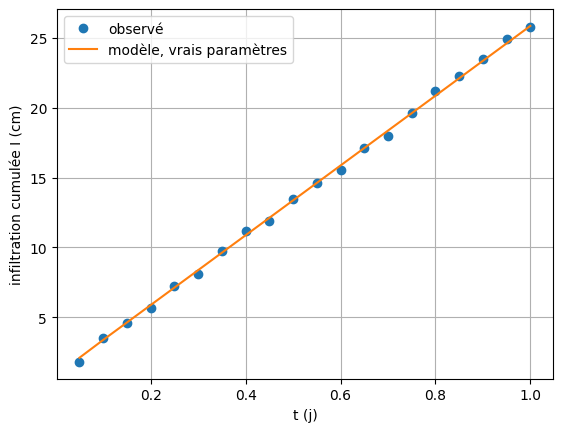

In [19]:
debut = time.time()
I_vrai, h_vrai = richards(0.036, 1.56, 24.96)
duree = time.time() - debut
rmse_I = np.sqrt(np.mean((I_vrai - I_obs) ** 2))
rmse_h = np.sqrt(np.mean((h_vrai - h_obs) ** 2))
print(f"un appel : {duree:.2f} s ; RMSE I = {rmse_I:.3f} cm (sigma 0,2) ; RMSE h = {rmse_h:.2f} cm (sigma 3)")

plt.figure()
plt.plot(t_obs, I_obs, "o", label="observé")
plt.plot(t_obs, I_vrai, "-", label="modèle, vrais paramètres")
plt.xlabel("t (j)")
plt.ylabel("infiltration cumulée I (cm)")
plt.legend()
plt.grid(True)
plt.show()

**2. Résidus pondérés et estimation par least_squares**

In [20]:
# résidus pondérés (observé - simulé) / sigma ; les paramètres sont passés en logarithme
# (ils restent positifs et ont le même ordre de grandeur)
def residu(log_parametres):
    alpha = np.exp(log_parametres[0])
    n = np.exp(log_parametres[1])
    Ks = np.exp(log_parametres[2])
    I_mod, h_mod = richards(alpha, n, Ks)
    r_I = (I_obs - I_mod) / sigma_I
    r_h = (h_obs - h_mod) / sigma_h
    return np.concatenate([r_I, r_h.ravel()])

depart = np.log([0.02, 1.8, 50.0])
borne_basse = np.log([0.005, 1.15, 2.0])
borne_haute = np.log([0.2, 3.0, 500.0])

debut = time.time()
res = least_squares(residu, depart, bounds=(borne_basse, borne_haute), diff_step=0.02, xtol=1e-4, ftol=1e-4, max_nfev=30)
duree = time.time() - debut
Phi_min = 2 * res.cost                   # somme des carrés des résidus pondérés
print(f"least_squares : {duree:.0f} s, {res.nfev} évaluations, statut {res.status} ; Phi_min = {Phi_min:.1f} pour N = {len(res.fun)} observations")

alpha_est = np.exp(res.x[0])
n_est = np.exp(res.x[1])
Ks_est = np.exp(res.x[2])
print(f"estimé : alpha = {alpha_est:.4f} (vrai 0,036), n = {n_est:.3f} (1,56), Ks = {Ks_est:.2f} cm/j (24,96)")

least_squares : 9 s, 14 évaluations, statut 3 ; Phi_min = 78.9 pour N = 80 observations
estimé : alpha = 0.0362 (vrai 0,036), n = 1.552 (1,56), Ks = 25.04 cm/j (24,96)


**3. Incertitudes : covariance, IC 95 % et corrélations**

In [21]:
J = res.jac                              # jacobien des résidus (N x 3)
N_obs = len(res.fun)
s2 = Phi_min / (N_obs - 3)               # variance résiduelle (≈ 1 si les sigma sont bien choisis)
cov = s2 * np.linalg.inv(J.T @ J)        # covariance des log-paramètres
se = np.sqrt(np.diag(cov))               # écarts-types des log-paramètres
corr = cov / np.outer(se, se)            # matrice de corrélation
ic95 = 100 * (np.exp(1.96 * se) - 1)     # intervalle de confiance à 95 % en % de la valeur estimée

tableau = pd.DataFrame({"estimé": [alpha_est, n_est, Ks_est], "vrai": [0.036, 1.56, 24.96], "IC95 relatif (%)": ic95},
                       index=["alpha", "n", "Ks"])
print(tableau.round(3))
print("corrélation :")
print(pd.DataFrame(corr, index=["alpha", "n", "Ks"], columns=["alpha", "n", "Ks"]).round(2))

       estimé    vrai  IC95 relatif (%)
alpha   0.036   0.036             3.958
n       1.552   1.560             1.644
Ks     25.042  24.960             0.789
corrélation :
       alpha     n    Ks
alpha   1.00 -0.61  0.72
n      -0.61  1.00 -0.65
Ks      0.72 -0.65  1.00


**Données et modèle ajusté**

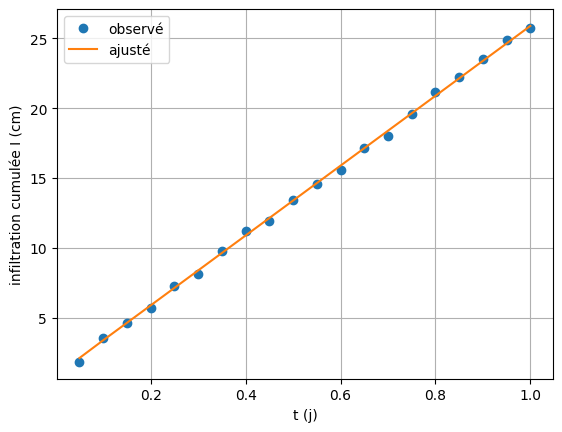

In [22]:
I_fit, h_fit = richards(alpha_est, n_est, Ks_est)

plt.figure()
plt.plot(t_obs, I_obs, "o", label="observé")
plt.plot(t_obs, I_fit, "-", label="ajusté")
plt.xlabel("t (j)")
plt.ylabel("infiltration cumulée I (cm)")
plt.legend()
plt.grid(True)
plt.show()

**Charges de pression observées et ajustées**

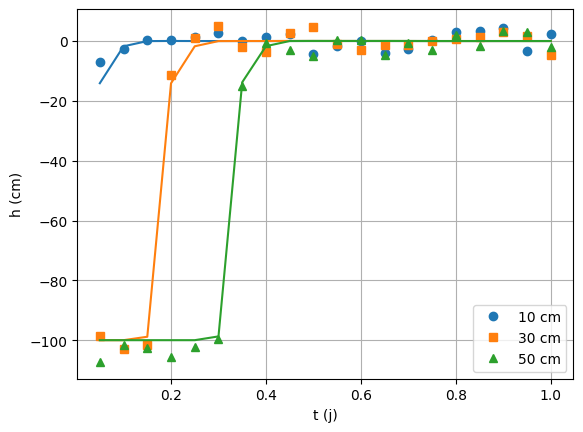

In [23]:
plt.figure()
plt.plot(t_obs, h_obs[:, 0], "o", color="C0", label="10 cm")
plt.plot(t_obs, h_fit[:, 0], "-", color="C0")
plt.plot(t_obs, h_obs[:, 1], "s", color="C1", label="30 cm")
plt.plot(t_obs, h_fit[:, 1], "-", color="C1")
plt.plot(t_obs, h_obs[:, 2], "^", color="C2", label="50 cm")
plt.plot(t_obs, h_fit[:, 2], "-", color="C2")
plt.xlabel("t (j)")
plt.ylabel("h (cm)")
plt.legend()
plt.grid(True)
plt.show()

**4. Estimation avec l'infiltration seule**

In [24]:
# résidus pondérés avec les seules données d'infiltration
def residu_I(log_parametres):
    alpha = np.exp(log_parametres[0])
    n = np.exp(log_parametres[1])
    Ks = np.exp(log_parametres[2])
    I_mod, h_mod = richards(alpha, n, Ks)
    return (I_obs - I_mod) / sigma_I

debut = time.time()
res_I = least_squares(residu_I, depart, bounds=(borne_basse, borne_haute), diff_step=0.02, xtol=1e-4, ftol=1e-4, max_nfev=30)
duree = time.time() - debut
print(f"I(t) seule : {duree:.0f} s, {res_I.nfev} évaluations ; estimé alpha = {np.exp(res_I.x[0]):.4f}, n = {np.exp(res_I.x[1]):.3f}, Ks = {np.exp(res_I.x[2]):.2f}")

J_I = res_I.jac
s2_I = 2 * res_I.cost / (len(res_I.fun) - 3)
cov_I = s2_I * np.linalg.inv(J_I.T @ J_I)
se_I = np.sqrt(np.diag(cov_I))
corr_I = cov_I / np.outer(se_I, se_I)
print("IC95 relatif (%) :", np.round(100 * (np.exp(1.96 * se_I) - 1), 1))
print("corrélation :")
print(pd.DataFrame(corr_I, index=["alpha", "n", "Ks"], columns=["alpha", "n", "Ks"]).round(2))

I(t) seule : 10 s, 14 évaluations ; estimé alpha = 0.0422, n = 1.556, Ks = 25.14
IC95 relatif (%) : [805.6  29.2   2.2]
corrélation :
       alpha     n    Ks
alpha   1.00  0.99 -0.89
n       0.99  1.00 -0.93
Ks     -0.89 -0.93  1.00


**Commentaire (instructeur).** Avec infiltration + tensiomètres, les trois paramètres sont retrouvés à 1–2 % près en une quinzaine d'évaluations (quelques secondes) :
IC à 95 % de ± 5 % sur $\alpha$, ± 1,5 % sur $n$ et ± 1 % sur $K_s$, corrélations de 0,6–0,8 (identifiabilité correcte). Avec $I(t)$ seule,
$K_s$ reste bien contraint (pente finale de $I$) mais $\alpha$ part vers 0,045–0,05 avec un IC de plusieurs centaines de pour cent et une
corrélation $\alpha$–$n$ de 0,99 : une infinité de couples ($\alpha$, $n$) donnent la même sorptivité. Dans HYDRUS-1D : Main Processes →
*Inverse Solution* ; cocher *Fitted* pour $\alpha$, $n$, $K_s$ avec bornes ; *Data for Inverse Solution* : type 0 (infiltration cumulée,
position 0) et type 1 ($h$ aux nœuds d'observation 1, 2, 3) avec poids $1/\sigma$ ; 15 itérations ; lire FIT.OUT (paramètres,
écarts-types, corrélations).

## Exercice 5 — Bonus — surface de réponse et identifiabilité  *(≈ facultatif)*

Calculer la fonction objectif $\Phi(\alpha, n)$ ($K_s$ = 24,96 fixé) sur une grille 6 × 6 ($\alpha \in [0{,}015 ; 0{,}07]$,
$n \in [1{,}25 ; 2{,}1]$) avec les données de $h$ et sans ; tracer $\log_{10}\Phi$ en isolignes et situer les vraies valeurs.
Commenter la forme des vallées.

**Calcul de la fonction objectif sur la grille**

In [25]:
alphas = np.linspace(0.015, 0.07, 6)
ns = np.linspace(1.25, 2.1, 6)
Phi_tous = np.zeros((6, 6))     # avec I et h
Phi_I = np.zeros((6, 6))        # avec I seule

debut = time.time()
for i in range(6):
    for j in range(6):
        r = residu(np.log([alphas[j], ns[i], 24.96]))
        Phi_tous[i, j] = np.sum(r ** 2)
        Phi_I[i, j] = np.sum(r[:20] ** 2)      # les 20 premiers résidus sont ceux de I(t)
print(f"36 simulations en {time.time() - debut:.0f} s")

36 simulations en 10 s


**Surface de réponse avec I(t) seule**

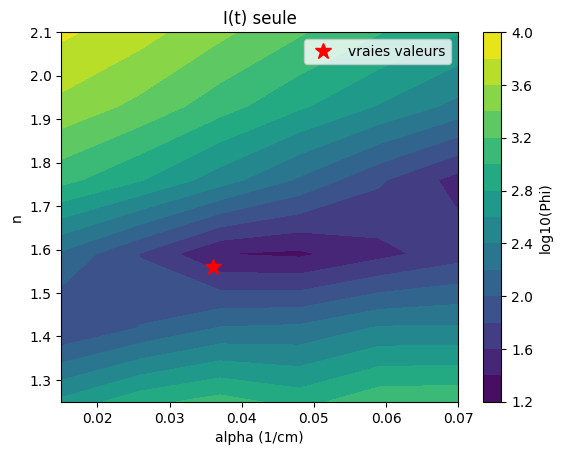

In [26]:
plt.figure()
plt.contourf(alphas, ns, np.log10(Phi_I), levels=15)
plt.colorbar(label="log10(Phi)")
plt.plot(0.036, 1.56, "r*", markersize=12, label="vraies valeurs")
plt.xlabel("alpha (1/cm)")
plt.ylabel("n")
plt.title("I(t) seule")
plt.legend()
plt.show()

**Surface de réponse avec I(t) et h**

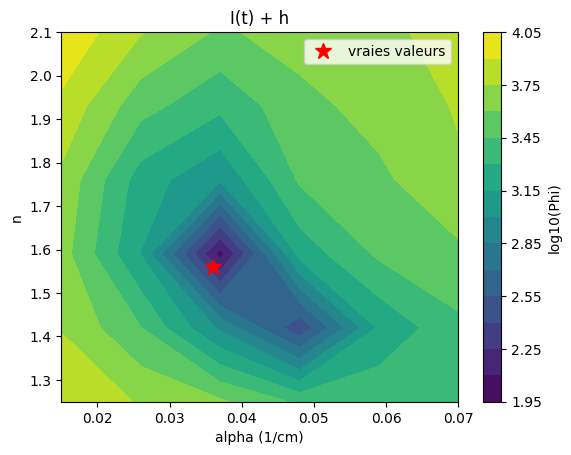

In [27]:
plt.figure()
plt.contourf(alphas, ns, np.log10(Phi_tous), levels=15)
plt.colorbar(label="log10(Phi)")
plt.plot(0.036, 1.56, "r*", markersize=12, label="vraies valeurs")
plt.xlabel("alpha (1/cm)")
plt.ylabel("n")
plt.title("I(t) + h")
plt.legend()
plt.show()

**Commentaire (instructeur).** Avec $I(t)$ seule, la surface présente une vallée allongée : $\Phi$ varie peu le long d'une courbe $\alpha$–$n$ (même sorptivité).
Avec les charges de pression, le minimum devient un puits bien fermé autour de (0,036 ; 1,56). C'est l'image géométrique de la corrélation
entre paramètres ; l'IC linéarisé de l'exercice 4 n'est fiable que si la vallée est à peu près elliptique près du minimum.

## Pour aller plus loin

* Ajouter $\theta_s$ aux paramètres ajustés : identifiable avec ces données ? Et $\theta_r$ ?
* Remplacer les données de $h$ par des teneurs en eau $\theta$ (sondes) : comparer les incertitudes.
* Estimer ($\lambda$, $R$, $\mu$) sur les BTC HYDRUS par `least_squares` autour d'un schéma numérique de l'ADE (Crank–Nicolson), puis avec
  un modèle mobile–immobile ($\theta_{im}$, $\alpha$) : quelles données permettent de distinguer les deux modèles ?
* Refaire l'exercice 4 dans HYDRUS-1D (Inverse Solution) et comparer FIT.OUT aux résultats Python.